# Sección 5: Proceso de Riesgo con Actividad Infinita

**Tesis:** Teoría del Riesgo y Probabilidad de Ruina — Una Aproximación vía Procesos de Lévy  
**Autor:** Luis Alvarez  
**Director:** Dr. Freddy Palma Mancilla

Esta sección trabaja con **datos simulados** para ilustrar
el comportamiento de un proceso de Lévy de actividad infinita
(proceso gamma) frente al modelo clásico de Cramér-Lundberg.

In [1]:
import numpy as np
from scipy import stats
from scipy.optimize import brentq
from scipy.stats import gamma as gamma_dist
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})
np.random.seed(123)

## 1. Parámetros del escenario simulado

Se elige un escenario con magnitudes manejables para que las gráficas sean legibles.  
Los parámetros no provienen del dataset — son ilustrativos.

In [13]:
# --- Parámetros de la simulación ---
# Escenario: aseguradora con ~5 siniestros/día, severidad media ~$2000
lam_sim    = 5.0          # tasa de Poisson (sin/día) para CL
mu_Y_sim   = 2000.0       # media de severidad
delta_sim  = 1 / mu_Y_sim # parámetro exponencial
theta_sim  = 0.30         # margen de seguridad 30%
beta_sim   = (1 + theta_sim) * lam_sim * mu_Y_sim  # prima/día

E_S1 = lam_sim * mu_Y_sim           # E[reclamaciones/día]
V_S1 = lam_sim * (2 * mu_Y_sim**2)  # Var[reclamaciones/día] bajo exp

print(f'lambda   = {lam_sim} sin/día')
print(f'mu_Y     = ${mu_Y_sim:,.0f}')
print(f'beta     = ${beta_sim:,.0f}/día')
print(f'E[S_1]   = ${E_S1:,.0f}/día')
print(f'Ganancia = ${beta_sim - E_S1:,.0f}/día')

lambda   = 5.0 sin/día
mu_Y     = $2,000
beta     = $13,000/día
E[S_1]   = $10,000/día
Ganancia = $3,000/día


## 2. Calibración del proceso gamma

$G_t \sim \text{Gamma}(at, b)$ con $E[G_1] = a/b$ y $\text{Var}(G_1) = a/b^2$.

In [14]:
b_gamma = E_S1 / V_S1
a_gamma = E_S1 * b_gamma

print(f'Proceso Gamma calibrado:')
print(f'  a = {a_gamma:.6f}')
print(f'  b = {b_gamma:.6f}')
print(f'  E[G_1] = {a_gamma/b_gamma:,.0f}  (target: {E_S1:,.0f})')
print(f'  Var[G_1] = {a_gamma/b_gamma**2:,.0f}  (target: {V_S1:,.0f})')

Proceso Gamma calibrado:
  a = 2.500000
  b = 0.000250
  E[G_1] = 10,000  (target: 10,000)
  Var[G_1] = 40,000,000  (target: 40,000,000)


## 3. Coeficientes de ajuste

In [15]:
# CL exponencial
R_CL = delta_sim - lam_sim / beta_sim

# Gamma: R*beta = -a*log(1 - R/b)
def lundberg_gamma(R, a, b, beta_val):
    if R <= 0 or R >= b:
        return np.inf
    return R * beta_val + a * np.log(1 - R / b)

R_gamma = brentq(lundberg_gamma, 1e-15, b_gamma - 1e-15,
                  args=(a_gamma, b_gamma, beta_sim))

# Difusión
mu_drift = beta_sim - E_S1
diff_CL = 2 * mu_drift / V_S1
diff_gamma = 2 * mu_drift / (a_gamma / b_gamma**2)  # Var[G_1] = a/b^2

print(f'R_CL     = {R_CL:.6e}')
print(f'R_Gamma  = {R_gamma:.6e}')
print(f'Dif_CL   = {diff_CL:.6e}')
print(f'Dif_Gamma = {diff_gamma:.6e}')

R_CL     = 1.153846e-04
R_Gamma  = 1.057425e-04
Dif_CL   = 1.500000e-04
Dif_Gamma = 1.500000e-04


## 4. Funciones de simulación

In [5]:
def simulate_CL_trajectory(u, beta_val, lam_val, delta, T):
    """Simula UNA trayectoria CL con detalle para graficar."""
    times = [0.0]
    surplus = [u]
    t_now, S_now = 0.0, 0.0
    while t_now < T:
        dt = np.random.exponential(1 / lam_val)
        t_now += dt
        if t_now > T:
            times.append(T)
            surplus.append(u + beta_val * T - S_now)
            break
        claim = np.random.exponential(1 / delta)
        # Antes del salto
        times.append(t_now)
        surplus.append(u + beta_val * t_now - S_now)
        S_now += claim
        # Después del salto
        times.append(t_now)
        surplus.append(u + beta_val * t_now - S_now)
    return np.array(times), np.array(surplus)


def simulate_gamma_trajectory(u, beta_val, a, b, T, dt=0.01):
    """Simula UNA trayectoria del superávit con proceso gamma."""
    n_steps = int(T / dt)
    times = np.linspace(0, T, n_steps + 1)
    shape_inc = a * dt
    scale_inc = 1.0 / b
    increments = gamma_dist.rvs(a=shape_inc, scale=scale_inc, size=n_steps)
    G = np.zeros(n_steps + 1)
    G[1:] = np.cumsum(increments)
    surplus = u + beta_val * times - G
    return times, surplus


def simulate_gamma_ruin_mc(u, beta_val, a, b, T, n_paths, dt=0.5):
    """Estima psi(u) para el proceso gamma por Monte Carlo."""
    n_steps = int(T / dt)
    times = np.linspace(0, T, n_steps + 1)
    shape_inc = a * dt
    scale_inc = 1.0 / b
    ruined = 0
    for _ in range(n_paths):
        G = 0.0
        is_ruined = False
        for i in range(1, n_steps + 1):
            G += gamma_dist.rvs(a=shape_inc, scale=scale_inc)
            if u + beta_val * times[i] - G < 0:
                is_ruined = True
                break
        if is_ruined:
            ruined += 1
    return ruined / n_paths


def simulate_CL_ruin_mc(u, beta_val, lam_val, delta, T, n_paths):
    """Estima psi(u) para CL por Monte Carlo."""
    ruined = 0
    for _ in range(n_paths):
        t_now, S_now = 0.0, 0.0
        is_ruined = False
        while t_now < T:
            t_now += np.random.exponential(1/lam_val)
            if t_now > T:
                break
            S_now += np.random.exponential(1/delta)
            if u + beta_val * t_now - S_now < 0:
                is_ruined = True
                break
        if is_ruined:
            ruined += 1
    return ruined / n_paths

## 5. GRÁFICA: Medida de Lévy — comparación

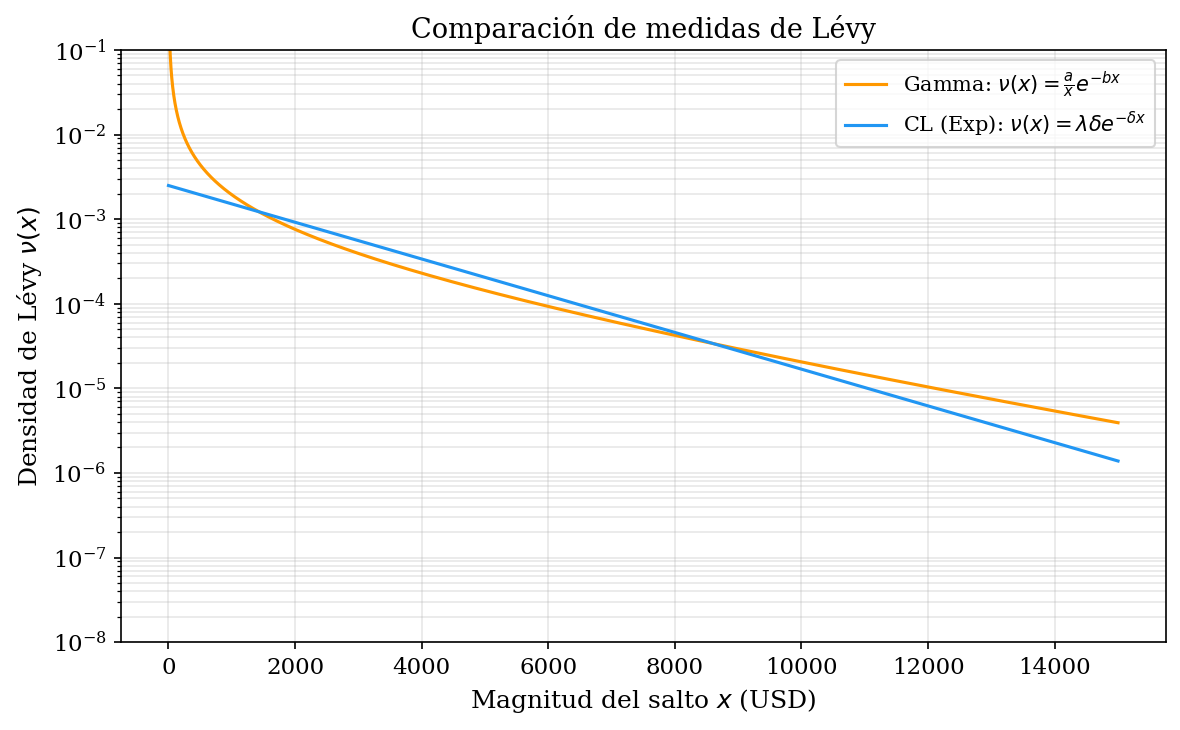

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

x_levy = np.linspace(1, 15000, 5000)

# Gamma: nu(x) = (a/x) * exp(-b*x)
nu_gamma = (a_gamma / x_levy) * np.exp(-b_gamma * x_levy)

# CL: nu(x) = lambda * delta * exp(-delta*x)
nu_CL = lam_sim * delta_sim * np.exp(-delta_sim * x_levy)

ax.semilogy(x_levy, nu_gamma, color='#FF9800', lw=1.5,
            label=r'Gamma: $\nu(x) = \frac{a}{x}e^{-bx}$')
ax.semilogy(x_levy, nu_CL, color='#2196F3', lw=1.5,
            label=r'CL (Exp): $\nu(x) = \lambda\delta e^{-\delta x}$')

ax.set_xlabel('Magnitud del salto $x$ (USD)')
ax.set_ylabel(r'Densidad de Lévy $\nu(x)$')
ax.set_title('Comparación de medidas de Lévy')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
ax.set_ylim(1e-8, 1e-1)
plt.tight_layout()
plt.savefig('GraficasSec5/fig_medida_levy.pdf')
plt.show()

## 6. GRÁFICA: Comparación de trayectorias CL vs Gamma (corto plazo)

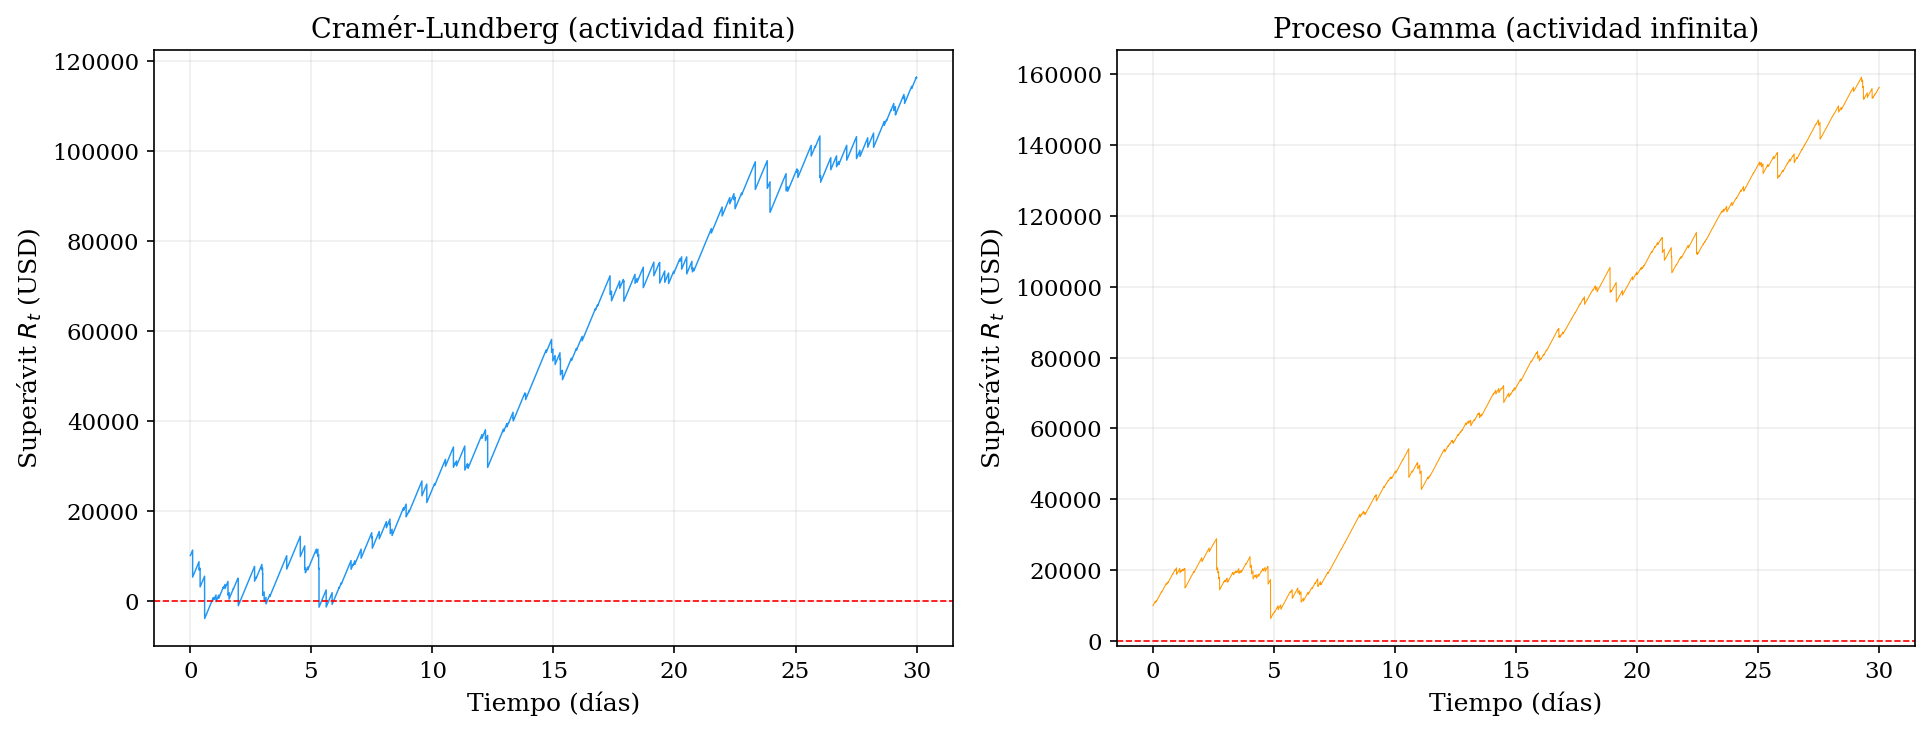

In [18]:
u_traj = 5 * mu_Y_sim  # $10,000
T_short = 30  # 1 mes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

np.random.seed(42)
t_cl, r_cl = simulate_CL_trajectory(u_traj, beta_sim, lam_sim, delta_sim, T_short)
ax1.plot(t_cl, r_cl, lw=0.7, color='#2196F3')
ax1.axhline(0, color='red', ls='--', lw=0.8)
ax1.set_xlabel('Tiempo (días)')
ax1.set_ylabel('Superávit $R_t$ (USD)')
ax1.set_title('Cramér-Lundberg (actividad finita)')
ax1.grid(True, alpha=0.2)

np.random.seed(42)
t_g, r_g = simulate_gamma_trajectory(u_traj, beta_sim, a_gamma, b_gamma, T_short, dt=0.005)
ax2.plot(t_g, r_g, lw=0.5, color='#FF9800')
ax2.axhline(0, color='red', ls='--', lw=0.8)
ax2.set_xlabel('Tiempo (días)')
ax2.set_ylabel('Superávit $R_t$ (USD)')
ax2.set_title('Proceso Gamma (actividad infinita)')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('GraficasSec5/fig_trayectorias_CL_vs_Gamma.pdf')
plt.show()

## 7. GRÁFICA: Trayectorias del proceso gamma (largo plazo)

<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:13: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Wisp8\AppData\Local\Temp\ipykernel_15596\401550069.py:13: SyntaxWarning: invalid escape sequence '\$'
  ax.set_title(f'Trayectorias del superávit — Proceso Gamma ($u_0 = \${u_traj:,.0f}$)')


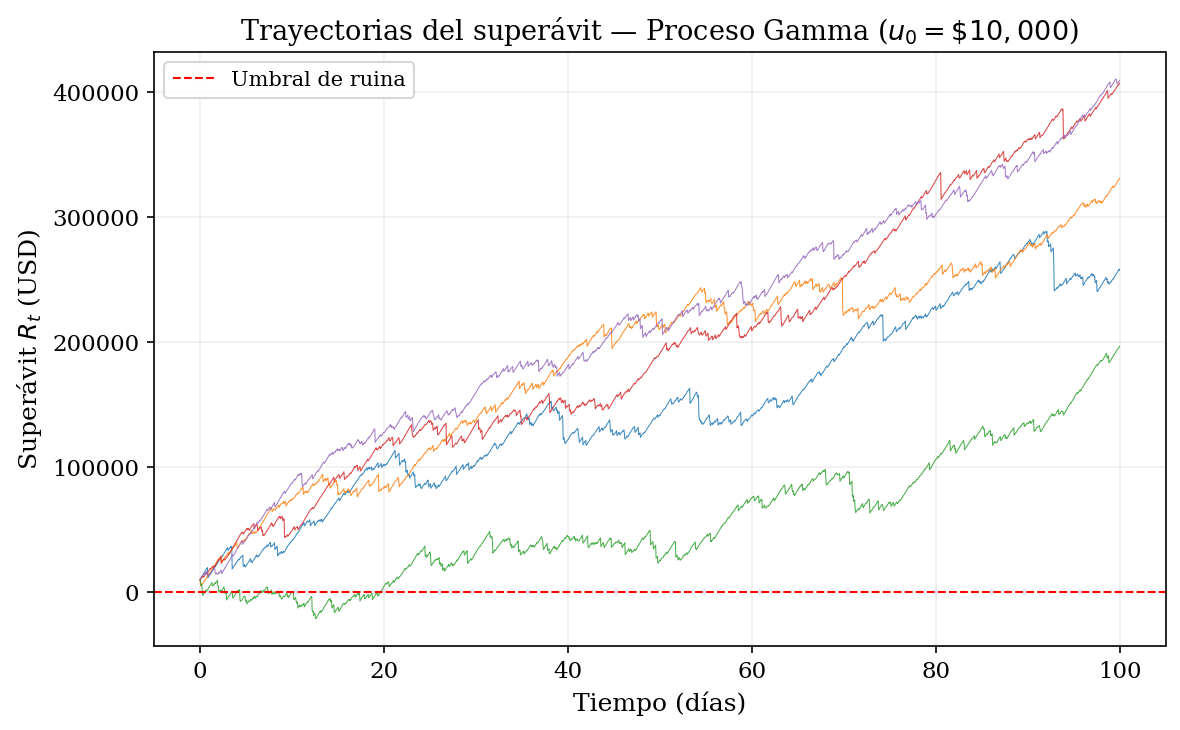

In [19]:
T_long = 100  # 1 año
n_show = 5

fig, ax = plt.subplots(figsize=(8, 5))
for k in range(n_show):
    t_g, r_g = simulate_gamma_trajectory(u_traj, beta_sim, a_gamma, b_gamma,
                                          T_long, dt=0.05)
    ax.plot(t_g, r_g, lw=0.5, alpha=0.85)

ax.axhline(0, color='red', ls='--', lw=1, label='Umbral de ruina')
ax.set_xlabel('Tiempo (días)')
ax.set_ylabel('Superávit $R_t$ (USD)')
ax.set_title(f'Trayectorias del superávit — Proceso Gamma ($u_0 = \${u_traj:,.0f}$)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('GraficasSec5/fig_trayectorias_gamma_largo.pdf')
plt.show()

## 8. GRÁFICA: Proceso gamma G_t (reclamaciones acumuladas)

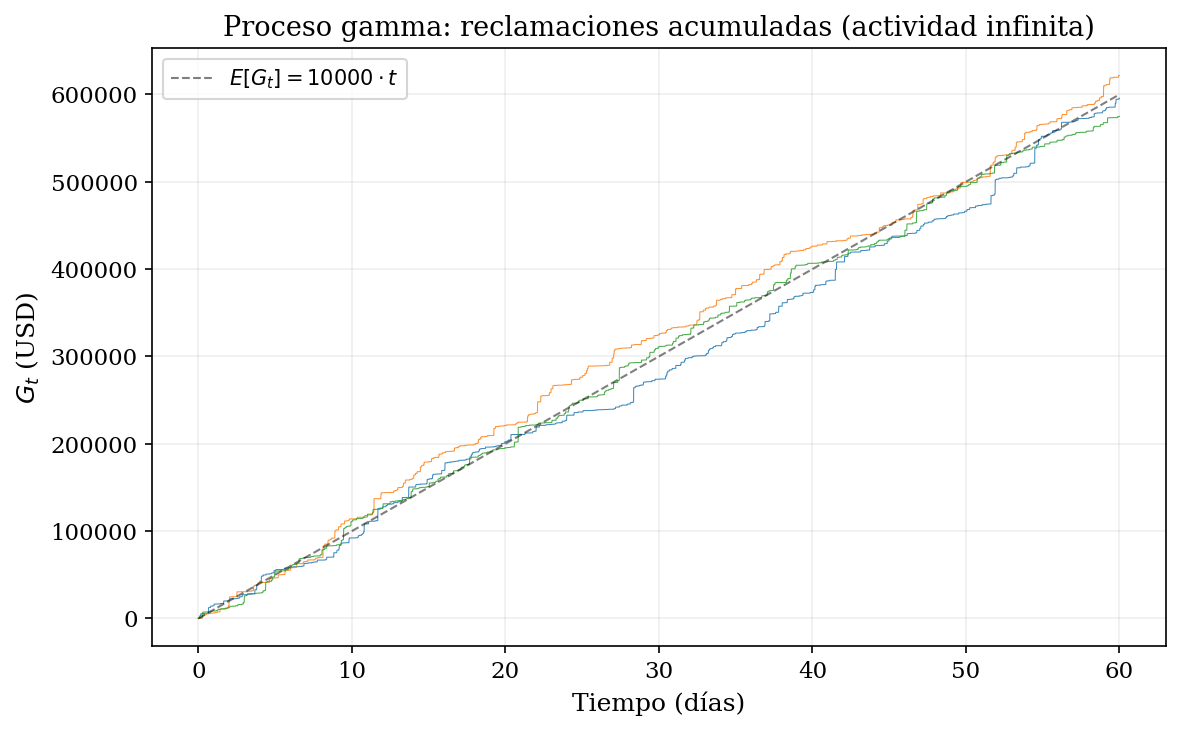

In [10]:
T_demo = 60
fig, ax = plt.subplots(figsize=(8, 5))

for k in range(3):
    n_steps = int(T_demo / 0.01)
    times = np.linspace(0, T_demo, n_steps + 1)
    shape_inc = a_gamma * 0.01
    scale_inc = 1.0 / b_gamma
    increments = gamma_dist.rvs(a=shape_inc, scale=scale_inc, size=n_steps)
    G = np.zeros(n_steps + 1)
    G[1:] = np.cumsum(increments)
    ax.plot(times, G, lw=0.5, alpha=0.85)

# Superponer E[G_t] = (a/b)*t
ax.plot(times, (a_gamma/b_gamma)*times, 'k--', lw=1, alpha=0.5,
        label=f'$E[G_t] = {a_gamma/b_gamma:.0f}\\cdot t$')

ax.set_xlabel('Tiempo (días)')
ax.set_ylabel('$G_t$ (USD)')
ax.set_title('Proceso gamma: reclamaciones acumuladas (actividad infinita)')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('GraficasSec5/fig_proceso_gamma_Gt.pdf')
plt.show()

## 9. GRÁFICA: Ecuación de Lundberg (visualización)

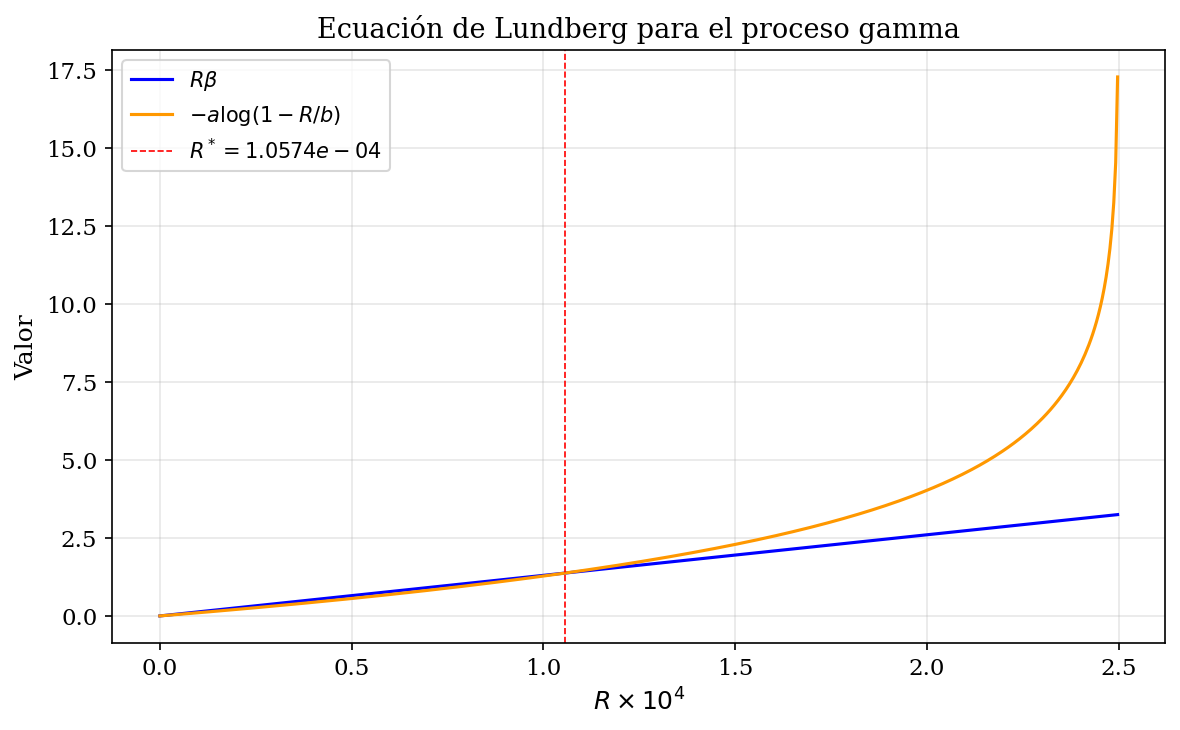

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

R_range = np.linspace(1e-8, b_gamma * 0.999, 500)
lhs = R_range * beta_sim
rhs = -a_gamma * np.log(1 - R_range / b_gamma)

ax.plot(R_range * 1e4, lhs, 'b-', lw=1.5, label=r'$R\beta$')
ax.plot(R_range * 1e4, rhs, color='#FF9800', lw=1.5,
        label=r'$-a\log(1 - R/b)$')
ax.axvline(R_gamma * 1e4, color='red', ls='--', lw=0.8,
           label=f'$R^* = {R_gamma:.4e}$')
ax.set_xlabel(r'$R \times 10^{4}$')
ax.set_ylabel('Valor')
ax.set_title('Ecuación de Lundberg para el proceso gamma')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('GraficasSec5/fig_lundberg_gamma.pdf')
plt.show()

## 10. Simulación Monte Carlo: probabilidad de ruina

In [12]:
T_horizon = 365 * 2  # 2 años
n_sim = 2_000

u_multiples = np.array([0, 1, 2, 5, 10, 15, 20])
u_values = u_multiples * mu_Y_sim

print(f'MC: {n_sim} trayectorias, T={T_horizon} días')
print(f'{"u":>10} | {"MC Gamma":>10} | {"Cota Γ":>10} | {"MC CL":>10} | {"Exacta CL":>10}')
print('-' * 60)

mc_gamma, mc_cl = [], []
psi_0_CL = lam_sim / (delta_sim * beta_sim)

for u in u_values:
    pg = simulate_gamma_ruin_mc(u, beta_sim, a_gamma, b_gamma, T_horizon, n_sim, dt=0.5)
    pc = simulate_CL_ruin_mc(u, beta_sim, lam_sim, delta_sim, T_horizon, n_sim)
    cota_g = np.exp(-R_gamma * u)
    exacta = psi_0_CL * np.exp(-R_CL * u)
    mc_gamma.append(pg)
    mc_cl.append(pc)
    print(f'{u:>10,.0f} | {pg:>10.5f} | {cota_g:>10.5f} | {pc:>10.5f} | {exacta:>10.5f}')

mc_gamma = np.array(mc_gamma)
mc_cl = np.array(mc_cl)

MC: 2000 trayectorias, T=730 días
         u |   MC Gamma |     Cota Γ |      MC CL |  Exacta CL
------------------------------------------------------------
         0 |    0.52900 |    1.00000 |    0.77000 |    0.76923
     2,000 |    0.45300 |    0.80938 |    0.62850 |    0.61071
     4,000 |    0.35650 |    0.65510 |    0.47700 |    0.48486
    10,000 |    0.19050 |    0.34735 |    0.23500 |    0.24263
    20,000 |    0.05600 |    0.12065 |    0.08000 |    0.07653
    30,000 |    0.02200 |    0.04191 |    0.02100 |    0.02414
    40,000 |    0.01100 |    0.01456 |    0.00800 |    0.00761


## 11. GRÁFICA: Probabilidad de ruina — escala lineal

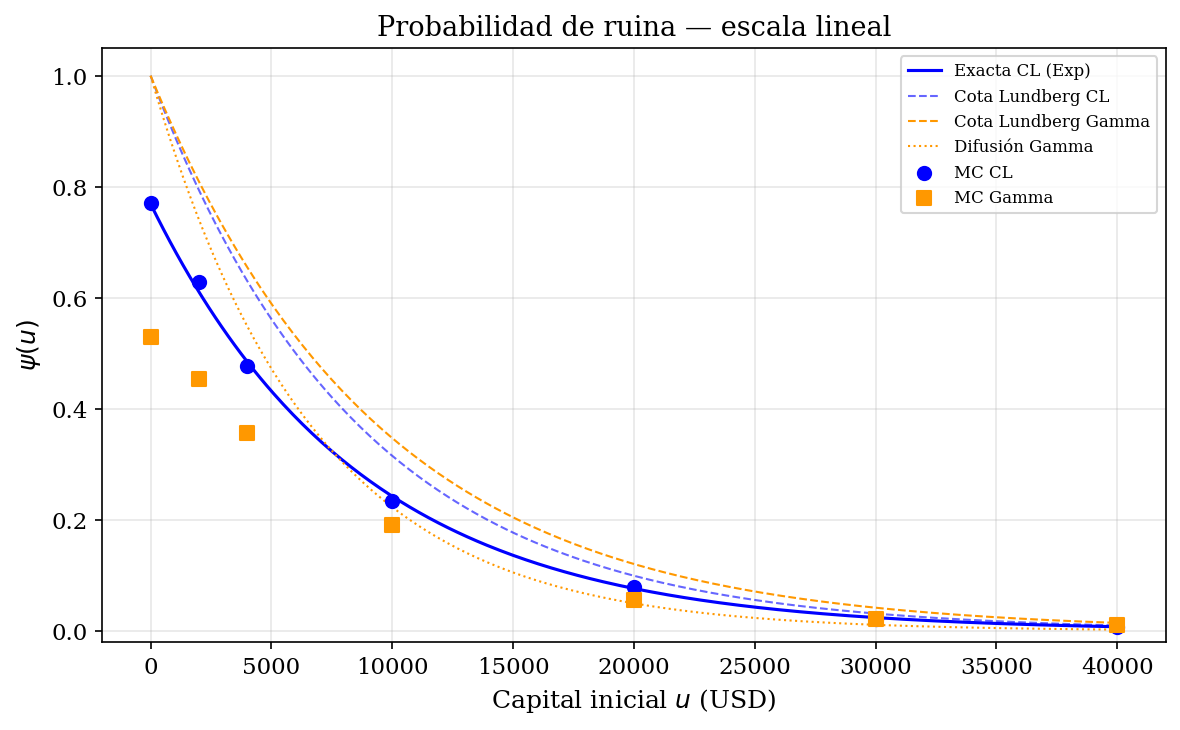

In [21]:
u_plot = np.linspace(0, 20 * mu_Y_sim, 300)

psi_exact_CL = psi_0_CL * np.exp(-R_CL * u_plot)
cota_CL_plot = np.exp(-R_CL * u_plot)
cota_gamma_plot = np.exp(-R_gamma * u_plot)
diff_gamma_plot = np.exp(-diff_gamma * u_plot)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(u_plot, psi_exact_CL, 'b-', lw=1.5, label='Exacta CL (Exp)')
ax.plot(u_plot, cota_CL_plot, 'b--', lw=1, alpha=0.6, label='Cota Lundberg CL')
ax.plot(u_plot, cota_gamma_plot, color='#FF9800', ls='--', lw=1,
        label='Cota Lundberg Gamma')
ax.plot(u_plot, diff_gamma_plot, color='#FF9800', ls=':', lw=1,
        label='Difusión Gamma')
ax.scatter(u_values, mc_cl, marker='o', s=40, color='blue', zorder=5, label='MC CL')
ax.scatter(u_values, mc_gamma, marker='s', s=40, color='#FF9800', zorder=5, label='MC Gamma')

ax.set_xlabel('Capital inicial $u$ (USD)')
ax.set_ylabel('$\\psi(u)$')
ax.set_title('Probabilidad de ruina — escala lineal')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.05)
plt.tight_layout()
plt.savefig('GraficasSec5/fig_psi_gamma_lineal.pdf')
plt.show()

## 12. GRÁFICA: Probabilidad de ruina — escala logarítmica

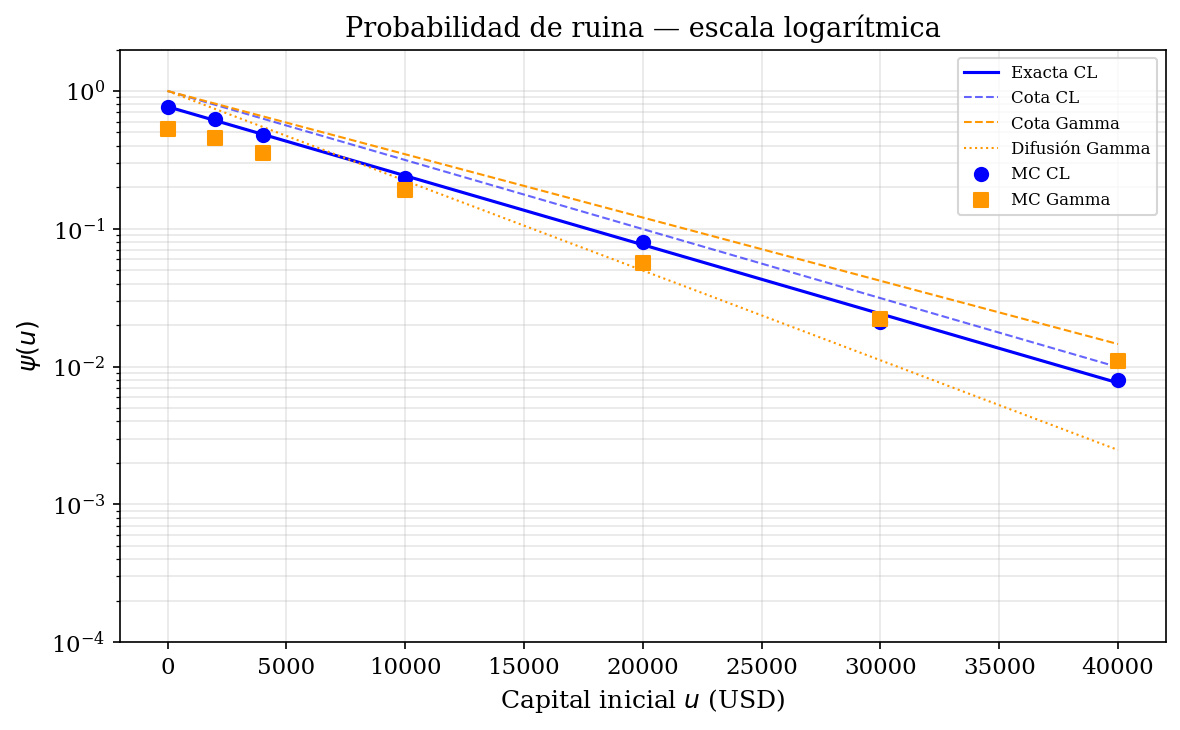

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogy(u_plot, np.clip(psi_exact_CL, 1e-8, 1), 'b-', lw=1.5, label='Exacta CL')
ax.semilogy(u_plot, np.clip(cota_CL_plot, 1e-8, 1), 'b--', lw=1, alpha=0.6, label='Cota CL')
ax.semilogy(u_plot, np.clip(cota_gamma_plot, 1e-8, 1), color='#FF9800',
            ls='--', lw=1, label='Cota Gamma')
ax.semilogy(u_plot, np.clip(diff_gamma_plot, 1e-8, 1), color='#FF9800',
            ls=':', lw=1, label='Difusión Gamma')

mask_cl = mc_cl > 0
mask_g = mc_gamma > 0
ax.scatter(u_values[mask_cl], mc_cl[mask_cl], marker='o', s=40, color='blue',
           zorder=5, label='MC CL')
ax.scatter(u_values[mask_g], mc_gamma[mask_g], marker='s', s=40, color='#FF9800',
           zorder=5, label='MC Gamma')

ax.set_xlabel('Capital inicial $u$ (USD)')
ax.set_ylabel('$\\psi(u)$')
ax.set_title('Probabilidad de ruina — escala logarítmica')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which='both')
ax.set_ylim(1e-4, 2)
plt.tight_layout()
plt.savefig('GraficasSec5/fig_psi_gamma_log.pdf')
plt.show()